# Notebook 3 — Model Creation, Hyperparameter Tuning & Evaluation


Model I will use: RandomForestClassifier  
Tuning Strategy: RandomizedSearchCV  
Evaluation Metric: F1 Score 

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

# 1. Load the Cleaned Data Set

Cleaned data is imported. Let's see how many transacations labeled as fraud remained with then new data set.

In [56]:
df = pd.read_csv('/Users/saadult/TLAB Financial Fraud Detection/TLAB-Financial--Fraud--Detection/data/cleaned_transactions.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print(f"Fraud rate: {df['isFraud'].mean() * 100:.4f}%")
df.head()

Shape: (2770409, 10)

Columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isAccountDrained', 'errorBalanceOrig', 'type_TRANSFER']
Fraud rate: 0.2965%


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isAccountDrained,errorBalanceOrig,type_TRANSFER
0,1,181.00,181.0,0.0,0.0,0.00,1,1,0.00,True
1,1,181.00,181.0,0.0,21182.0,0.00,1,1,0.00,False
2,1,229133.94,15325.0,0.0,5083.0,51513.44,0,1,213808.94,False
3,1,215310.30,705.0,0.0,22425.0,0.00,0,1,214605.30,True
4,1,311685.89,10835.0,0.0,6267.0,2719172.89,0,1,300850.89,True


## 2. Define the Features and Target.

In [ ]:

y = df['isFraud']

# Features — drop the target
X = df.drop(columns=['isFraud'])

print('Features:', X.columns.tolist())
print('X shape:', X.shape)
print('y shape:', y.shape)

Features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isAccountDrained', 'errorBalanceOrig', 'type_TRANSFER']
X shape: (2770409, 9)
y shape: (2770409,)


# 3. Split the Test and Training Data

In the previous notebooks I mentioned how there is severe imbalance within the data because of how small the amount of transactions that are fraud vs legit. Because we want to preserve as much of the fraud data as we can, we do not want a random split for our model to train on. Having a random split with skew the results, to prevent this we are going to add the stratify=y to make sure that the fraud accounts are distributed evenly between test and split.

**After various attempts to touble shooting (Make sure that n_jobs=-1 so that all the CPU cores are being used, and CV is lower to minimize the time it takes when running hyperparameters) 

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.9,
    random_state=42,
    stratify=y
)

print('Training set size:', X_train.shape)
print('Test set size:    ', X_test.shape)
print('\nFraud rate in training set: {:.4f}%'.format(y_train.mean() * 100))
print('Fraud rate in test set:     {:.4f}%'.format(y_test.mean() * 100))

Training set size: (277040, 9)
Test set size:     (2493369, 9)

Fraud rate in training set: 0.2963%
Fraud rate in test set:     0.2965%


We double check and make sure that that the fraud rate is preserved and even within both sets

# 4. Modeling Baseline: Random Forest 

Lets us also account for the imbalance with "class_weight"= balanced. 

In [61]:
baseline_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

baseline_rf.fit(X_train, y_train)
y_pred_baseline = baseline_rf.predict(X_test)

baseline_f1 = f1_score(y_test, y_pred_baseline)
print(baseline_f1)

0.9979666531110207


# 5. Baseline Confusion Matrix 

Lets look at our false positives and negatives.

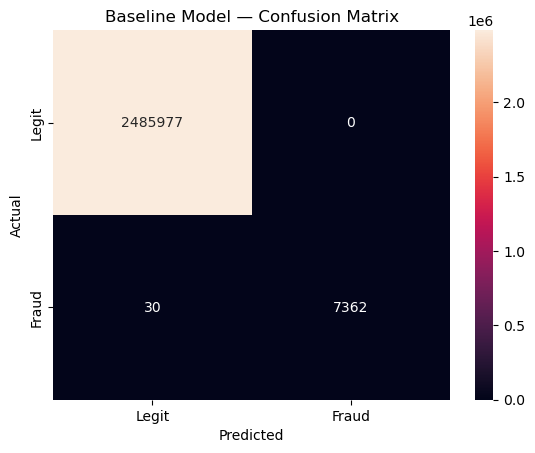

In [59]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

sns.heatmap(cm_baseline, annot=True, fmt='d',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Baseline Model — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 6. Hyperparameter Tuning: RandomizedSearchCV

In [62]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    verbose=2
)

search.fit(X_train, y_train)
print('\nBest Parameters:', search.best_params_)
print('Best CV F1 Score:', round(search.best_score_, 3))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=   5.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=   5.6s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=   5.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=   5.0s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, 

: 